# Team 20 — C-LSTM Deep Learning Notebook
## Deep Learning-Based Multi-Class Network Intrusion Detection | NSL-KDD

C-LSTM is the team's **proposed deep learning model** (1D-CNN + LSTM).  
This notebook implements the full C-LSTM pipeline and improvement roadmap:

| Section | Contents |
|---|---|
| 0 | Setup & Data Loading |
| 1 | Preprocessing (scaling, SMOTE only — no class weights) |
| 2 | C-LSTM Baseline |
| 3 | Hyperparameter Tuning |
| 4 | C-BiLSTM (Bidirectional) |
| 5 | C-LSTM + Self-Attention |
| 6 | Focal Loss |
| 7 | CNN-Transformer |
| 8 | Architecture Comparison & Final Evaluation |

> **Colab tip:** Runtime → Change runtime type → **T4 GPU** cuts training time ~4×.  
> **Key design choice:** SMOTE rebalances the training set — no class-weighted loss on top (they compound and cause precision collapse).

## 0 · Setup

In [ ]:
!pip install pandas numpy scikit-learn imbalanced-learn seaborn matplotlib tqdm -q

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings, time
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from imblearn.over_sampling import SMOTE

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"PyTorch: {torch.__version__}")

Device : cuda
PyTorch: 2.10.0+cu128


## 0b · Data Loading

In [ ]:
from google.colab import files
uploaded = files.upload()   # upload KDDTrain+.txt  (KDDTest+.txt is optional)

Saving KDDTrain+.txt to KDDTrain+.txt


In [ ]:
# ── Load NSL-KDD ──
df_train = pd.read_csv("KDDTrain+.txt", header=None)

try:
    df_test       = pd.read_csv("KDDTest+.txt", header=None)
    X_raw_test    = df_test.iloc[:, :-2]
    y_raw_test    = df_test.iloc[:, -2]
    using_kddtest = True
    print("KDDTest+.txt loaded ✓")
except FileNotFoundError:
    using_kddtest = False
    print("KDDTest+.txt not found — using 20% held-out split from KDDTrain+.txt")

X_raw_train = df_train.iloc[:, :-2]
y_raw_train = df_train.iloc[:, -2]

# ── Encode labels ──
le = LabelEncoder()
if using_kddtest:
    le.fit(pd.concat([y_raw_train, y_raw_test]))
else:
    le.fit(y_raw_train)

y_train_all = le.transform(y_raw_train)

# ── One-hot encode categorical features ──
X_all = pd.concat([X_raw_train, X_raw_test], axis=0) if using_kddtest else X_raw_train
X_enc = pd.get_dummies(X_all)
X_enc.columns = X_enc.columns.astype(str)

X_train_all = X_enc.iloc[:len(df_train)].values

if using_kddtest:
    X_test_all  = X_enc.iloc[len(df_train):].values
    y_test_full = le.transform(y_raw_test)
else:
    X_train_all, X_test_all, y_train_all, y_test_full = train_test_split(
        X_train_all, y_train_all,
        test_size=0.20, random_state=SEED, stratify=y_train_all)

target_names = list(le.classes_)
num_classes  = len(target_names)
print(f"Train : {X_train_all.shape}")
print(f"Test  : {X_test_all.shape}")
print(f"Classes ({num_classes}): {target_names}")

KDDTest+.txt not found — using 20% held-out split from KDDTrain+.txt
Train : (100778, 122)
Test  : (25195, 122)
Classes (23): ['back', 'buffer_overflow', 'ftp_write', 'guess_passwd', 'imap', 'ipsweep', 'land', 'loadmodule', 'multihop', 'neptune', 'nmap', 'normal', 'perl', 'phf', 'pod', 'portsweep', 'rootkit', 'satan', 'smurf', 'spy', 'teardrop', 'warezclient', 'warezmaster']


---
## 1 · Preprocessing
> **Runtime: ~3 min** (SMOTE)

**Design choice — SMOTE only, no class-weighted loss:**  
Using SMOTE *and* inverse-frequency class weights simultaneously compounds minority-class emphasis and causes precision collapse on majority classes (e.g. `normal` → 0.00 F1). SMOTE alone rebalances the training distribution; CrossEntropyLoss runs unweighted on top.

In [ ]:
# ── Train / Validation split ──
X_train, X_val, y_train, y_val = train_test_split(
    X_train_all, y_train_all,
    test_size=0.10, random_state=SEED, stratify=y_train_all)

# ── Feature scaling — fit on train only ──
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test_all)

print(f"Train : {X_train_sc.shape}")
print(f"Val   : {X_val_sc.shape}")
print(f"Test  : {X_test_sc.shape}")

Train : (90700, 122)
Val   : (10078, 122)
Test  : (25195, 122)


In [ ]:
# ── Capped SMOTE (training set only) ──
# Cap: minority classes upsampled to at most 10% of majority count.
# Classes with < 6 samples removed (SMOTE hard minimum of k_neighbors=5).
# NO class-weighted loss used alongside SMOTE — they compound each other.

unique_cls, cls_counts = np.unique(y_train, return_counts=True)
valid_cls  = unique_cls[cls_counts >= 6]
mask       = np.isin(y_train, valid_cls)
X_tr_f, y_tr_f = X_train_sc[mask], y_train[mask]

unique_f, counts_f = np.unique(y_tr_f, return_counts=True)
cap   = max(int(counts_f.max() * 0.10), 6)
strat = {cls: max(cap, cnt) for cls, cnt in zip(unique_f, counts_f)}

smote = SMOTE(sampling_strategy=strat, random_state=SEED, k_neighbors=5)
X_tr_res, y_tr_res = smote.fit_resample(X_tr_f, y_tr_f)

removed = len(unique_cls) - len(valid_cls)
print(f"Removed {removed} ultra-rare class(es) with < 6 samples.")
print(f"Original  train shape : {X_train_sc.shape}")
print(f"Resampled train shape : {X_tr_res.shape}")

Removed 5 ultra-rare class(es) with < 6 samples.
Original  train shape : (90700, 122)
Resampled train shape : (155728, 122)


In [ ]:
# ── Tensors ──
def to_tensors(X, y):
    X = np.nan_to_num(X.astype(np.float32))
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

X_tr_t, y_tr_t = to_tensors(X_tr_res, y_tr_res)
X_va_t, y_va_t = to_tensors(X_val_sc,  y_val)
X_te_t, y_te_t = to_tensors(X_test_sc, y_test_full)

input_dim = X_tr_t.shape[1]
print(f"Input dim  : {input_dim}")
print(f"Num classes: {num_classes}")

Input dim  : 122
Num classes: 23


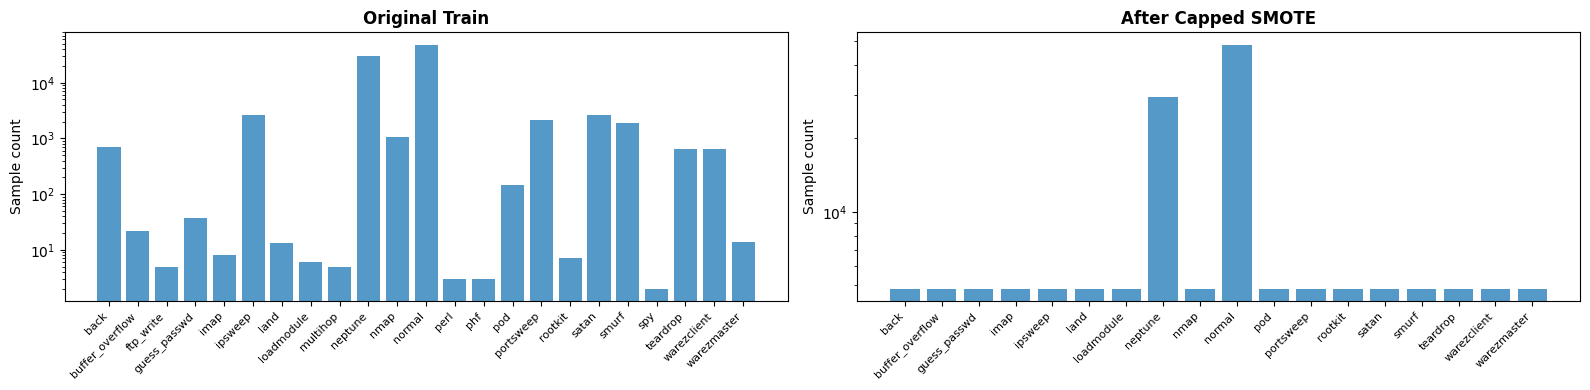

In [ ]:
# ── Class distribution before / after SMOTE ──
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for ax, (y, title) in zip(axes, [(y_train, 'Original Train'),
                                   (y_tr_res, 'After Capped SMOTE')]):
    uc, cc = np.unique(y, return_counts=True)
    names  = [target_names[i] for i in uc]
    ax.bar(names, cc, color='#2980b9', alpha=0.8)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Sample count')
    ax.set_yscale('log')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

---
## Shared Training Utilities
> Run once — used by every architecture.

In [ ]:
def make_loader(X_t, y_t, batch_size=512):
    return DataLoader(TensorDataset(X_t, y_t),
                      batch_size=batch_size, shuffle=True)

def train_model(model, loader, X_va, y_va,
                epochs=20, lr=1e-3, criterion=None, verbose=True):
    """
    Generic training loop with ReduceLROnPlateau scheduling
    and best-validation-loss checkpoint.

    Uses plain CrossEntropyLoss by default — SMOTE already rebalanced
    the training set, so additional class weighting is not needed.
    """
    if criterion is None:
        criterion = nn.CrossEntropyLoss()   # unweighted — SMOTE handles imbalance

    opt   = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=3)

    best_val, best_epoch, best_state = float('inf'), 1, None
    tl_hist, vl_hist = [], []
    t0 = time.time()

    for epoch in range(epochs):
        # ── Training ──
        model.train()
        running = 0.0
        for bx, by in loader:
            bx, by = bx.to(device), by.to(device)
            opt.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            opt.step()
            running += loss.item()
        tl = running / len(loader)
        tl_hist.append(tl)

        # ── Validation ──
        model.eval()
        vl = 0.0
        with torch.no_grad():
            for i in range(0, len(X_va), 512):
                bx = X_va[i:i+512].to(device)
                by = y_va[i:i+512].to(device)
                vl += criterion(model(bx), by).item()
        vl /= (len(X_va) // 512 + 1)
        vl_hist.append(vl)
        sched.step(vl)

        if vl < best_val:
            best_val   = vl
            best_epoch = epoch + 1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if verbose and (epoch + 1) % 5 == 0:
            tag = ' ← best' if epoch + 1 == best_epoch else ''
            print(f"  Ep {epoch+1:>2}/{epochs} | Train {tl:.4f} | Val {vl:.4f}{tag}")

    model.load_state_dict(best_state)
    print(f"  Best val loss: {best_val:.4f} at epoch {best_epoch}"
          f" | {(time.time()-t0)/60:.1f} min")
    return model, tl_hist, vl_hist

def evaluate(model, X_t, y_np, split_name="Test"):
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_t), 512):
            _, p = torch.max(model(X_t[i:i+512].to(device)), 1)
            preds.extend(p.cpu().numpy())
    preds   = np.array(preds)
    present = sorted(np.unique(np.concatenate([y_np, preds])))
    names   = [target_names[i] for i in present]
    macro   = f1_score(y_np, preds, average='macro',    zero_division=0)
    wtd     = f1_score(y_np, preds, average='weighted', zero_division=0)
    print(f"\n── {split_name} ──")
    print(f"  Macro F1    : {macro:.4f}")
    print(f"  Weighted F1 : {wtd:.4f}")
    print(classification_report(y_np, preds, labels=present,
                                target_names=names, zero_division=0))
    return preds, macro, wtd

def plot_losses(tl, vl, title):
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(range(1, len(tl)+1), tl, label='Train',      color='#3498db', lw=2)
    ax.plot(range(1, len(vl)+1), vl, label='Validation', color='#e74c3c', lw=2, ls='--')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.set_title(title, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    fname = title.lower().replace(' ','_').replace('+','').replace('/','') + '_loss.png'
    plt.savefig(fname, dpi=150)
    plt.show()

def plot_cm(y_true, y_pred, title, cmap='Blues'):
    cm      = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    present = np.where(cm.sum(axis=1) + cm.sum(axis=0) > 0)[0]
    names   = [target_names[i] for i in present]
    cm_sub  = cm[np.ix_(present, present)]
    fig, ax = plt.subplots(figsize=(16, 12))
    sns.heatmap(cm_sub, annot=False, fmt='d', cmap=cmap,
                xticklabels=names, yticklabels=names, ax=ax)
    ax.set_title(title, fontweight='bold', fontsize=14)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('True', fontsize=11)
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    fname = title.lower().replace(' ','_').replace('+','').replace('/','') + '_cm.png'
    plt.savefig(fname, dpi=150)
    plt.show()

loader = make_loader(X_tr_t, y_tr_t)
print("Utilities ready ✓")

Utilities ready ✓


---
## 2 · C-LSTM Baseline
*1D-CNN → LSTM → Dropout → FC*  
> **Runtime: ~5 min on T4 GPU | ~20 min on CPU**

In [ ]:
class CLSTM(nn.Module):
    """
    Hybrid CNN-LSTM for tabular intrusion detection.

    Flow:
      [batch, features]
        → unsqueeze(1)  →  [batch, 1, features]
        → Conv1d(1→64, k=3) + BatchNorm + ReLU + MaxPool(2)
        → permute  →  [batch, seq=features//2, 64]
        → LSTM(input=64, hidden=128)
        → last hidden state  →  [batch, 128]
        → Dropout(0.3) → Linear(128→64) → ReLU → Linear(64→num_classes)
    """
    def __init__(self, input_size, num_classes,
                 cnn_filters=64, lstm_hidden=128, dropout=0.3):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, cnn_filters, kernel_size=3, padding=1),
            nn.BatchNorm1d(cnn_filters),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )
        self.lstm = nn.LSTM(cnn_filters, lstm_hidden,
                            num_layers=1, batch_first=True)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_hidden, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.cnn(x.unsqueeze(1))      # [B, 64, seq]
        x = x.permute(0, 2, 1)            # [B, seq, 64]
        out, _ = self.lstm(x)
        return self.classifier(out[:, -1, :])

baseline = CLSTM(input_dim, num_classes).to(device)
total_params = sum(p.numel() for p in baseline.parameters() if p.requires_grad)
print(f"C-LSTM parameters: {total_params:,}")

C-LSTM parameters: 109,463


  Ep  5/20 | Train 0.1292 | Val 0.0854 ← best
  Ep 10/20 | Train 0.1083 | Val 0.0734
  Ep 15/20 | Train 0.0533 | Val 0.0473
  Ep 20/20 | Train 0.0377 | Val 0.0373 ← best
  Best val loss: 0.0373 at epoch 20 | 1.8 min


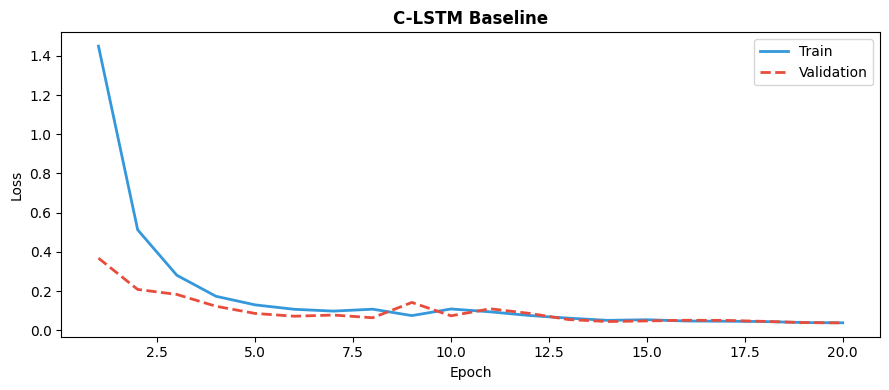

In [ ]:
baseline, tl_base, vl_base = train_model(
    baseline, loader, X_va_t, y_va_t, epochs=20)
plot_losses(tl_base, vl_base, 'C-LSTM Baseline')


── C-LSTM Baseline ──
  Macro F1    : 0.6910
  Weighted F1 : 0.9900
                 precision    recall  f1-score   support

           back       0.91      0.99      0.95       191
buffer_overflow       0.11      0.67      0.18         6
      ftp_write       0.00      0.00      0.00         2
   guess_passwd       1.00      1.00      1.00        11
           imap       1.00      1.00      1.00         2
        ipsweep       0.97      0.97      0.97       720
           land       0.67      1.00      0.80         4
     loadmodule       0.20      0.50      0.29         2
       multihop       0.00      0.00      0.00         1
        neptune       1.00      1.00      1.00      8243
           nmap       0.93      0.97      0.95       299
         normal       1.00      0.99      0.99     13469
            phf       0.00      0.00      0.00         1
            pod       0.98      1.00      0.99        40
      portsweep       0.98      0.97      0.98       586
        rootkit   

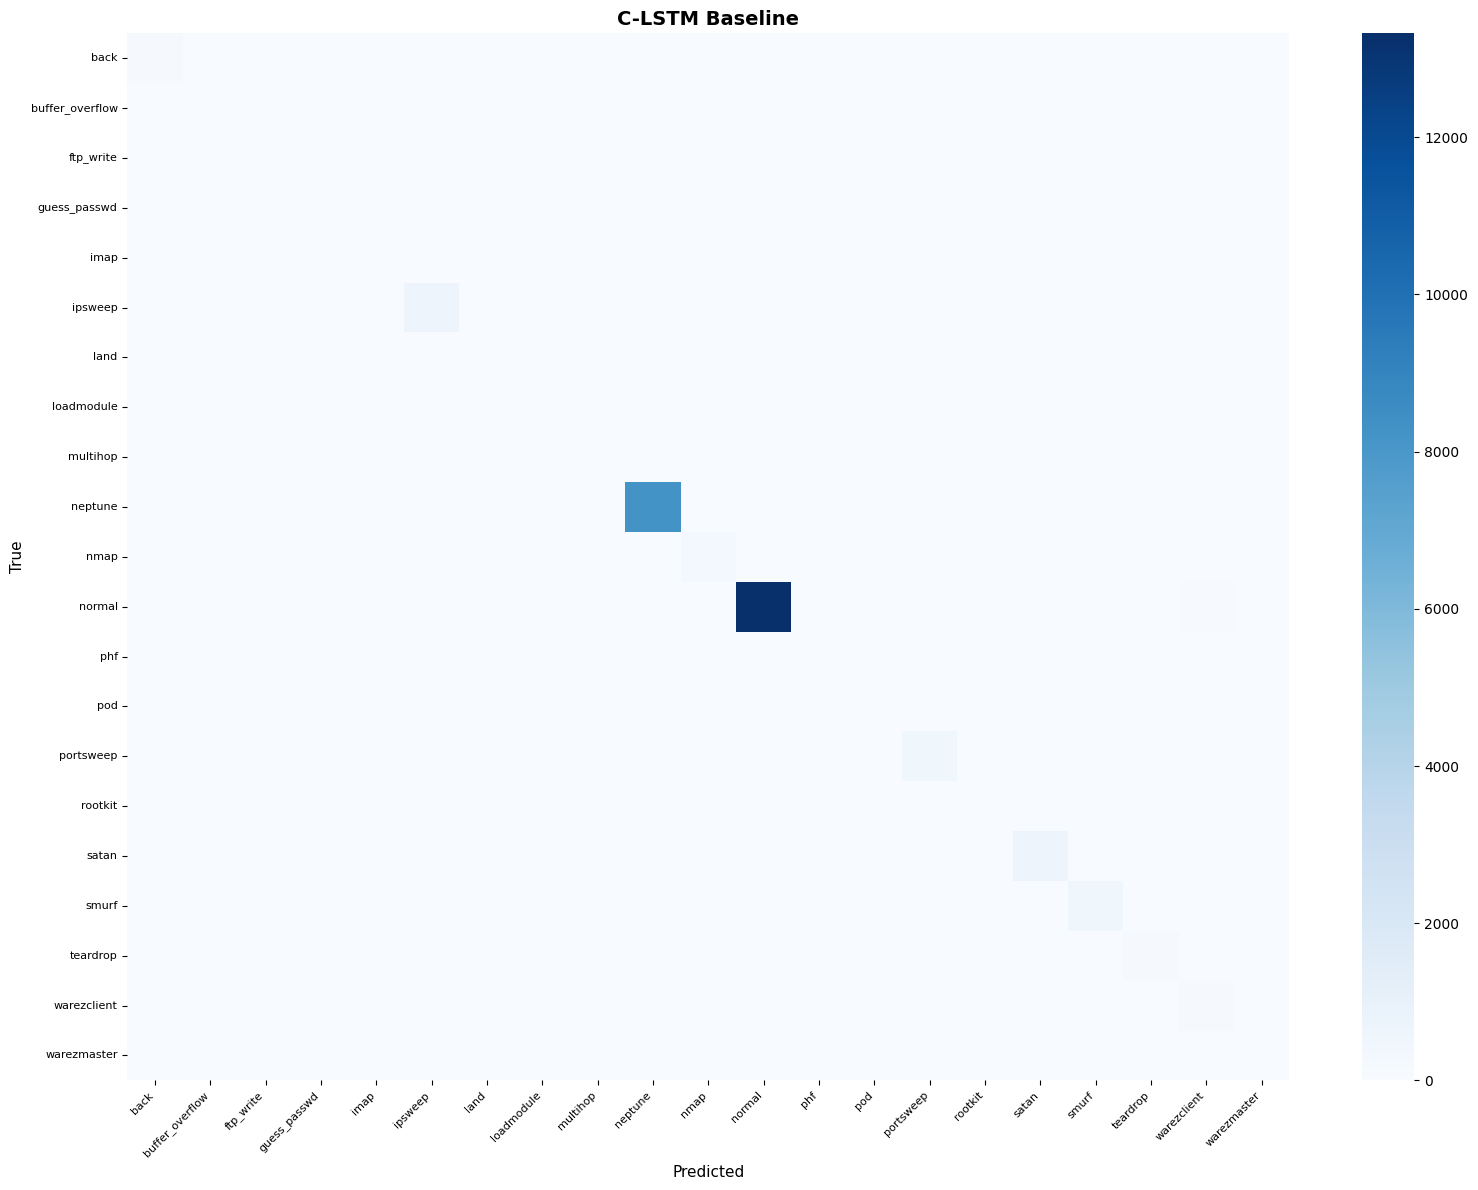

Saved: clstm_baseline.pt


In [ ]:
preds_base, macro_base, wtd_base = evaluate(
    baseline, X_te_t, y_test_full, "C-LSTM Baseline")
plot_cm(y_test_full, preds_base, 'C-LSTM Baseline', cmap='Blues')
torch.save(baseline.state_dict(), 'clstm_baseline.pt')
print("Saved: clstm_baseline.pt")

---
## 3 · C-LSTM Hyperparameter Tuning
> **Runtime: ~20 min on T4 GPU** (4 configs × 15 epochs each)

In [ ]:
configs = [
    {'cnn_filters': 64,  'lstm_hidden': 128, 'dropout': 0.3, 'lr': 1e-3, 'label': 'Base (64/128/0.3)'},
    {'cnn_filters': 128, 'lstm_hidden': 256, 'dropout': 0.3, 'lr': 1e-3, 'label': 'Wide (128/256/0.3)'},
    {'cnn_filters': 64,  'lstm_hidden': 128, 'dropout': 0.4, 'lr': 5e-4, 'label': 'RegLR (64/128/0.4)'},
    {'cnn_filters': 128, 'lstm_hidden': 128, 'dropout': 0.2, 'lr': 1e-3, 'label': 'LowDrop (128/128/0.2)'},
]
hp_results = []

for cfg in configs:
    print(f"\nTraining: {cfg['label']}")
    m = CLSTM(input_dim, num_classes,
              cnn_filters=cfg['cnn_filters'],
              lstm_hidden=cfg['lstm_hidden'],
              dropout=cfg['dropout']).to(device)
    m, _, _ = train_model(m, loader, X_va_t, y_va_t,
                           epochs=15, lr=cfg['lr'])
    _, macro, wtd = evaluate(m, X_te_t, y_test_full, cfg['label'])
    cfg.update({'macro_f1': macro, 'weighted_f1': wtd, 'model': m})
    hp_results.append(cfg)

best_hp = max(hp_results, key=lambda c: c['macro_f1'])
print(f"\nBest config : {best_hp['label']}")
print(f"  Macro F1  : {best_hp['macro_f1']:.4f}")
print(f"  Weighted F1: {best_hp['weighted_f1']:.4f}")


Training: Base (64/128/0.3)
  Ep  5/15 | Train 0.1206 | Val 0.0852 ← best
  Ep 10/15 | Train 0.0710 | Val 0.0545
  Ep 15/15 | Train 0.0549 | Val 0.0541
  Best val loss: 0.0489 at epoch 14 | 1.4 min

── Base (64/128/0.3) ──
  Macro F1    : 0.6679
  Weighted F1 : 0.9880
                 precision    recall  f1-score   support

           back       0.90      0.99      0.95       191
buffer_overflow       0.09      0.67      0.15         6
      ftp_write       0.00      0.00      0.00         2
   guess_passwd       0.73      1.00      0.85        11
           imap       1.00      1.00      1.00         2
        ipsweep       0.95      0.97      0.96       720
           land       0.80      1.00      0.89         4
     loadmodule       0.00      0.00      0.00         2
       multihop       0.00      0.00      0.00         1
        neptune       1.00      1.00      1.00      8243
           nmap       0.94      0.97      0.96       299
         normal       0.99      0.99      0.9

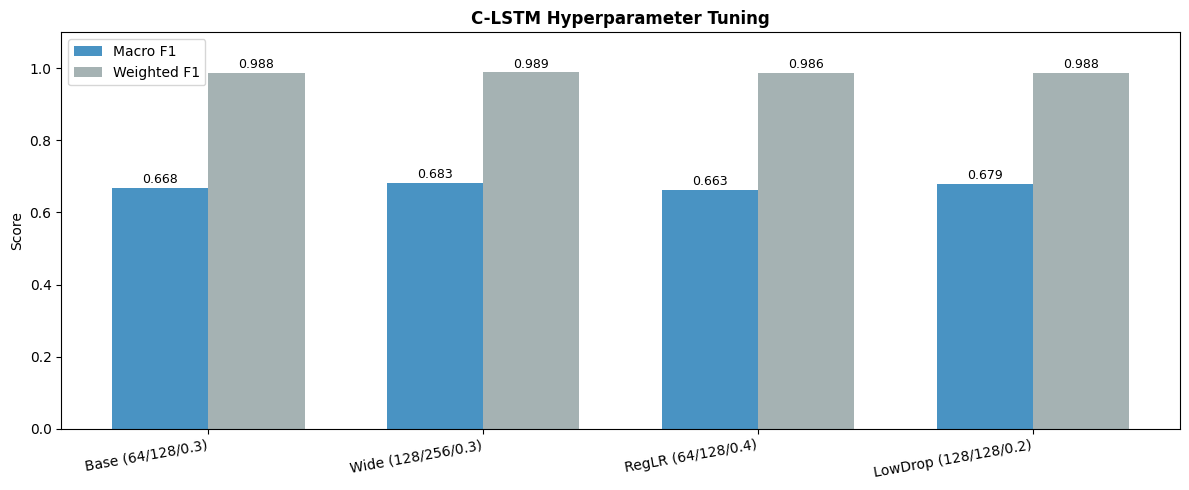

In [ ]:
labels = [c['label'] for c in hp_results]
macros = [c['macro_f1'] for c in hp_results]
wtds   = [c['weighted_f1'] for c in hp_results]

x, w = np.arange(len(labels)), 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w/2, macros, w, label='Macro F1',    color='#2980b9', alpha=0.85)
ax.bar(x + w/2, wtds,   w, label='Weighted F1', color='#95a5a6', alpha=0.85)
for i, (m, wt) in enumerate(zip(macros, wtds)):
    ax.text(i-w/2, m+0.005,  f'{m:.3f}',  ha='center', va='bottom', fontsize=9)
    ax.text(i+w/2, wt+0.005, f'{wt:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=10, ha='right')
ax.set_ylabel('Score'); ax.set_ylim(0, 1.1)
ax.set_title('C-LSTM Hyperparameter Tuning', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('hp_tuning.png', dpi=150)
plt.show()

---
## 4 · C-BiLSTM (Bidirectional LSTM)
*Processes the CNN feature sequence in both directions — doubles effective context.*  
> **Runtime: ~6 min on T4 GPU**

In [ ]:
class CLSTMBi(nn.Module):
    """
    Bidirectional LSTM variant.
    Output dimension is lstm_hidden * 2 (forward + backward concatenated).
    """
    def __init__(self, input_size, num_classes,
                 cnn_filters=64, lstm_hidden=128, dropout=0.3):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, cnn_filters, kernel_size=3, padding=1),
            nn.BatchNorm1d(cnn_filters), nn.ReLU(), nn.MaxPool1d(2),
        )
        self.lstm = nn.LSTM(cnn_filters, lstm_hidden,
                            num_layers=1, batch_first=True,
                            bidirectional=True)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_hidden * 2, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.cnn(x.unsqueeze(1)).permute(0, 2, 1)
        out, _ = self.lstm(x)
        return self.classifier(out[:, -1, :])

bilstm = CLSTMBi(input_dim, num_classes).to(device)
print(f"C-BiLSTM parameters: {sum(p.numel() for p in bilstm.parameters() if p.requires_grad):,}")

C-BiLSTM parameters: 216,983


  Ep  5/20 | Train 0.1530 | Val 0.1062 ← best
  Ep 10/20 | Train 0.0796 | Val 0.0711 ← best
  Ep 15/20 | Train 0.0599 | Val 0.0575 ← best
  Ep 20/20 | Train 0.0573 | Val 0.0483 ← best
  Best val loss: 0.0483 at epoch 20 | 3.0 min


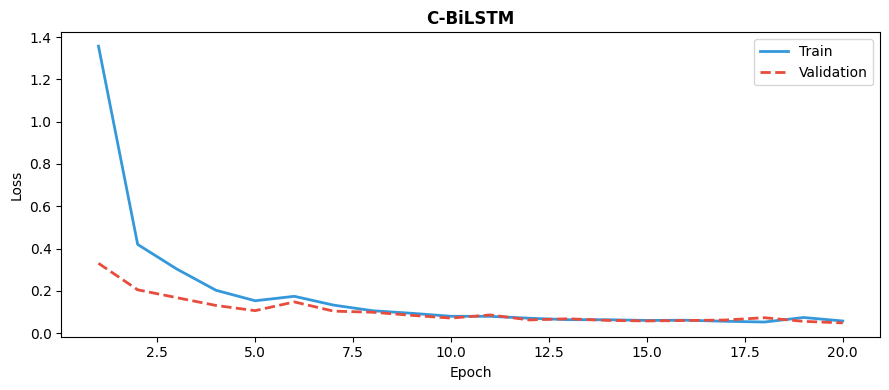


── C-BiLSTM ──
  Macro F1    : 0.6597
  Weighted F1 : 0.9876
                 precision    recall  f1-score   support

           back       0.93      0.99      0.96       191
buffer_overflow       0.11      0.83      0.19         6
      ftp_write       0.00      0.00      0.00         2
   guess_passwd       0.92      1.00      0.96        11
           imap       1.00      1.00      1.00         2
        ipsweep       0.95      0.97      0.96       720
           land       0.80      1.00      0.89         4
     loadmodule       0.00      0.00      0.00         2
       multihop       0.00      0.00      0.00         1
        neptune       1.00      1.00      1.00      8243
           nmap       0.92      0.97      0.94       299
         normal       1.00      0.98      0.99     13469
            phf       0.00      0.00      0.00         1
            pod       0.98      1.00      0.99        40
      portsweep       0.98      0.97      0.97       586
        rootkit       0.0

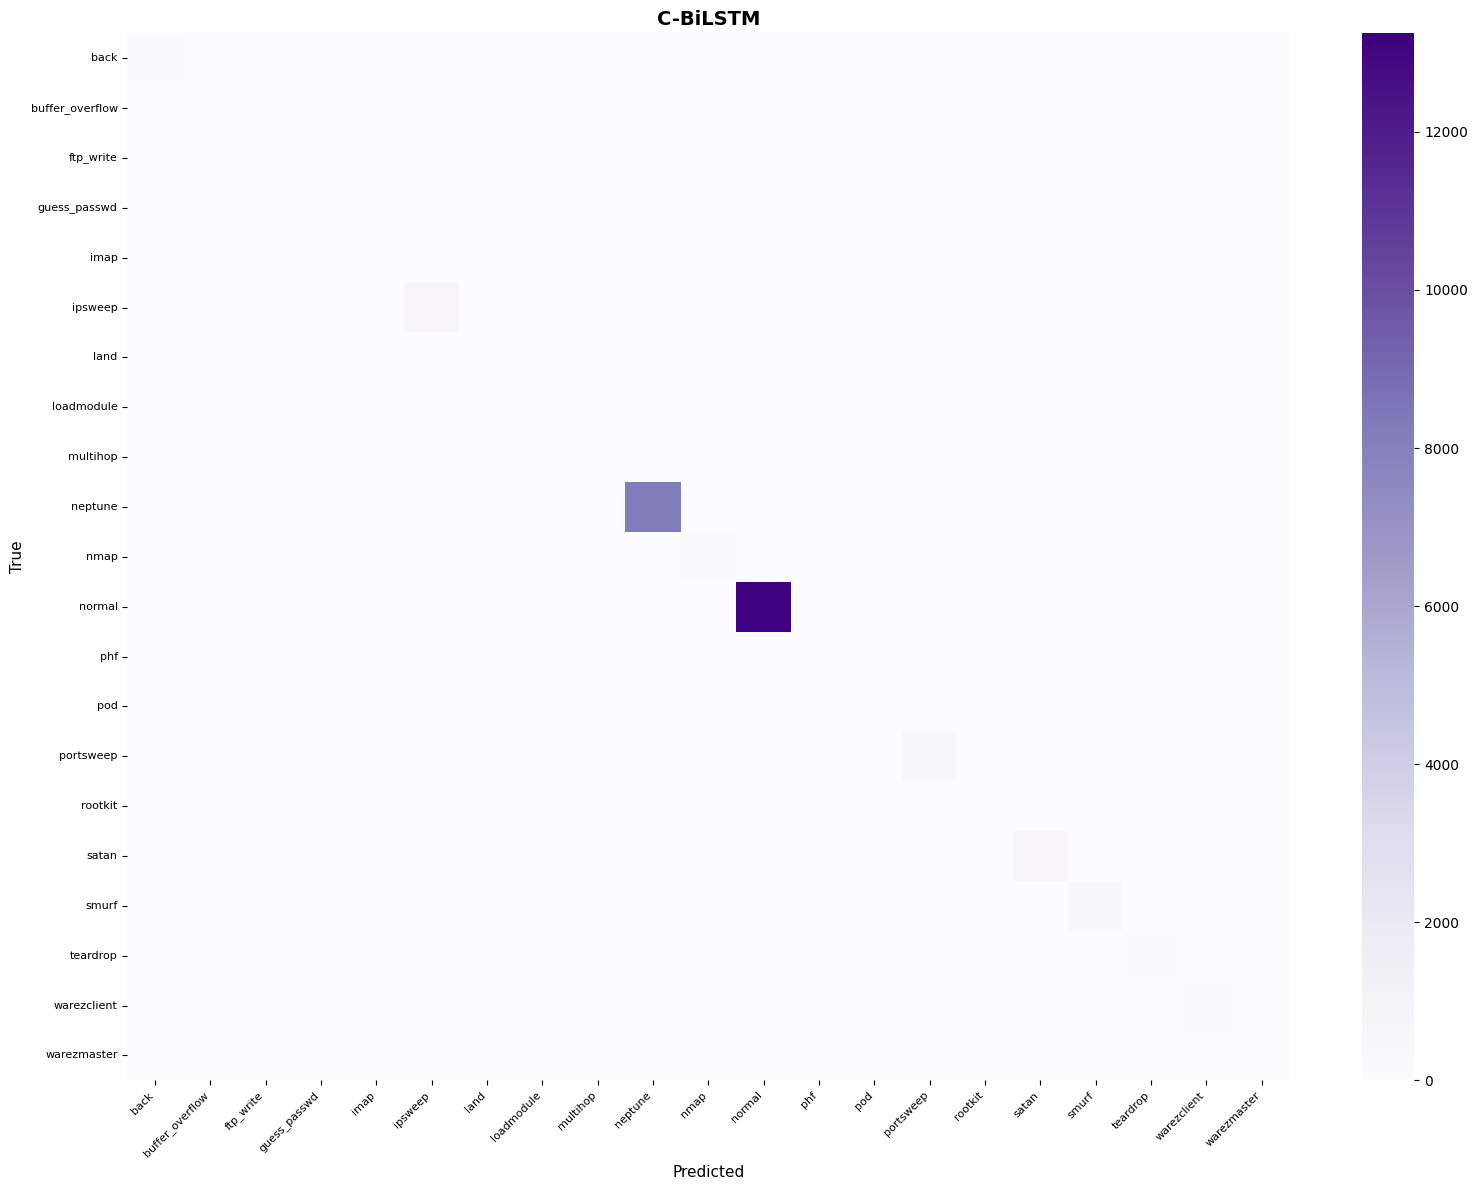

In [ ]:
bilstm, tl_bi, vl_bi = train_model(bilstm, loader, X_va_t, y_va_t, epochs=20)
plot_losses(tl_bi, vl_bi, 'C-BiLSTM')
preds_bi, macro_bi, wtd_bi = evaluate(bilstm, X_te_t, y_test_full, "C-BiLSTM")
plot_cm(y_test_full, preds_bi, 'C-BiLSTM', cmap='Purples')
torch.save(bilstm.state_dict(), 'clstm_bilstm.pt')

---
## 5 · C-LSTM + Self-Attention
*Additive self-attention over all LSTM time steps instead of discarding all but the last hidden state.*  
> **Runtime: ~6 min on T4 GPU**

In [ ]:
class AdditiveAttention(nn.Module):
    """
    Bahdanau-style additive attention.
    Learns a scalar score per time step and returns a weighted context vector.
    """
    def __init__(self, hidden_size):
        super().__init__()
        self.score = nn.Linear(hidden_size, 1)

    def forward(self, lstm_out):
        # lstm_out: [B, seq, hidden]
        weights = torch.softmax(self.score(lstm_out).squeeze(-1), dim=-1)  # [B, seq]
        context = (lstm_out * weights.unsqueeze(-1)).sum(dim=1)            # [B, hidden]
        return context

class CLSTMAttn(nn.Module):
    """C-LSTM with additive attention pooling over the full LSTM sequence."""
    def __init__(self, input_size, num_classes,
                 cnn_filters=64, lstm_hidden=128, dropout=0.3):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, cnn_filters, kernel_size=3, padding=1),
            nn.BatchNorm1d(cnn_filters), nn.ReLU(), nn.MaxPool1d(2),
        )
        self.lstm      = nn.LSTM(cnn_filters, lstm_hidden, batch_first=True)
        self.attention = AdditiveAttention(lstm_hidden)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_hidden, 64), nn.ReLU(),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.cnn(x.unsqueeze(1)).permute(0, 2, 1)
        out, _ = self.lstm(x)
        context = self.attention(out)
        return self.classifier(context)

attn = CLSTMAttn(input_dim, num_classes).to(device)
print(f"C-LSTM+Attn parameters: {sum(p.numel() for p in attn.parameters() if p.requires_grad):,}")

C-LSTM+Attn parameters: 109,592


  Ep  5/20 | Train 0.1041 | Val 0.1023
  Ep 10/20 | Train 0.0555 | Val 0.0533
  Ep 15/20 | Train 0.0365 | Val 0.0388 ← best
  Ep 20/20 | Train 0.0339 | Val 0.0337
  Best val loss: 0.0318 at epoch 19 | 2.0 min


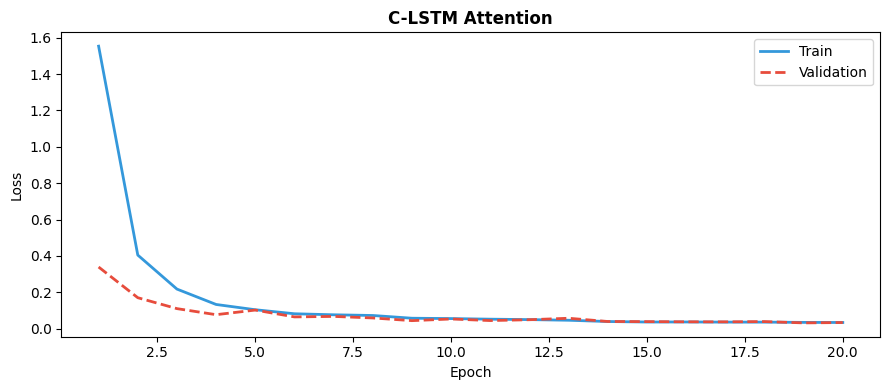


── C-LSTM+Attention ──
  Macro F1    : 0.6799
  Weighted F1 : 0.9914
                 precision    recall  f1-score   support

           back       0.97      0.99      0.98       191
buffer_overflow       0.12      0.83      0.21         6
      ftp_write       0.00      0.00      0.00         2
   guess_passwd       0.79      1.00      0.88        11
           imap       1.00      1.00      1.00         2
        ipsweep       0.98      0.96      0.97       720
           land       0.67      1.00      0.80         4
     loadmodule       0.00      0.00      0.00         2
       multihop       0.00      0.00      0.00         1
        neptune       1.00      1.00      1.00      8243
           nmap       0.89      0.97      0.93       299
         normal       1.00      0.99      0.99     13469
            phf       0.00      0.00      0.00         1
            pod       1.00      1.00      1.00        40
      portsweep       1.00      0.99      0.99       586
        rootkit  

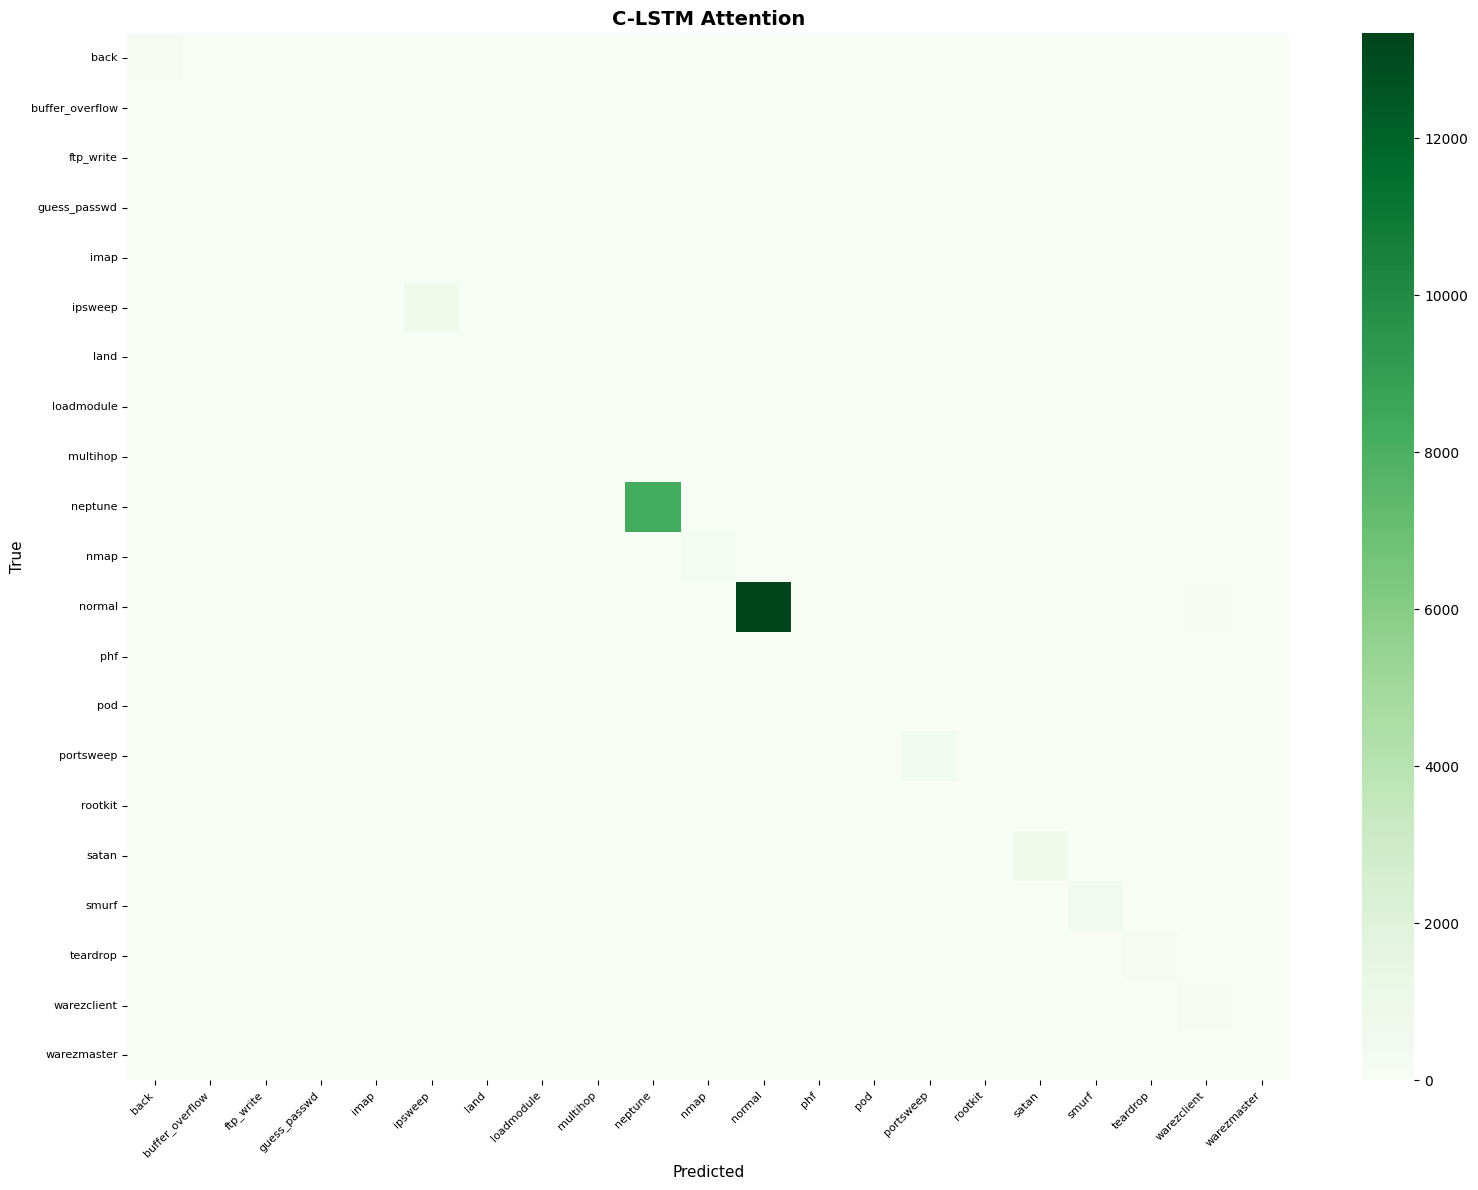

In [ ]:
attn, tl_attn, vl_attn = train_model(attn, loader, X_va_t, y_va_t, epochs=20)
plot_losses(tl_attn, vl_attn, 'C-LSTM Attention')
preds_attn, macro_attn, wtd_attn = evaluate(attn, X_te_t, y_test_full, "C-LSTM+Attention")
plot_cm(y_test_full, preds_attn, 'C-LSTM Attention', cmap='Greens')
torch.save(attn.state_dict(), 'clstm_attn.pt')

---
## 6 · C-LSTM + Focal Loss
*Focal Loss (γ=2) down-weights easy examples and forces the model to focus on hard minority-class samples (U2R, R2L). Used here **without** additional class weighting.*  
> **Runtime: ~6 min on T4 GPU**

  Ep  5/20 | Train 0.1110 | Val 0.0690 ← best
  Ep 10/20 | Train 0.0421 | Val 0.0437 ← best
  Ep 15/20 | Train 0.0281 | Val 0.0277
  Ep 20/20 | Train 0.0296 | Val 0.0257
  Best val loss: 0.0194 at epoch 19 | 1.9 min


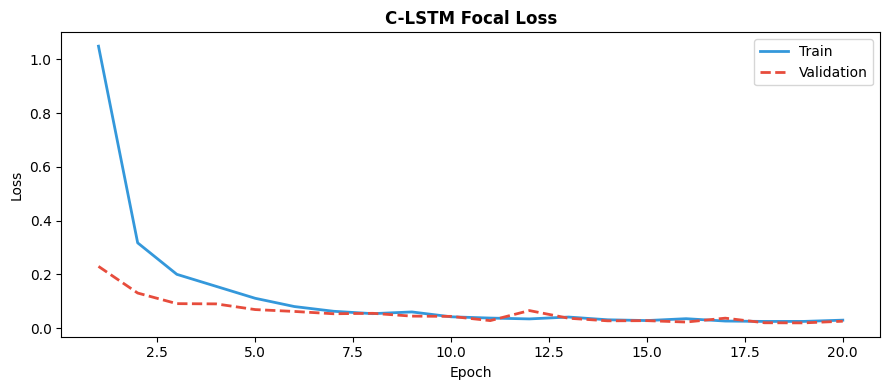


── C-LSTM+FocalLoss ──
  Macro F1    : 0.6816
  Weighted F1 : 0.9867
                 precision    recall  f1-score   support

           back       0.90      0.99      0.95       191
buffer_overflow       0.09      0.50      0.15         6
      ftp_write       0.00      0.00      0.00         2
   guess_passwd       0.79      1.00      0.88        11
           imap       1.00      1.00      1.00         2
        ipsweep       0.96      0.97      0.96       720
           land       0.80      1.00      0.89         4
     loadmodule       0.25      0.50      0.33         2
       multihop       0.00      0.00      0.00         1
        neptune       1.00      1.00      1.00      8243
           nmap       0.90      0.96      0.93       299
         normal       0.99      0.98      0.99     13469
            phf       0.00      0.00      0.00         1
            pod       1.00      1.00      1.00        40
      portsweep       0.97      0.98      0.97       586
        rootkit  

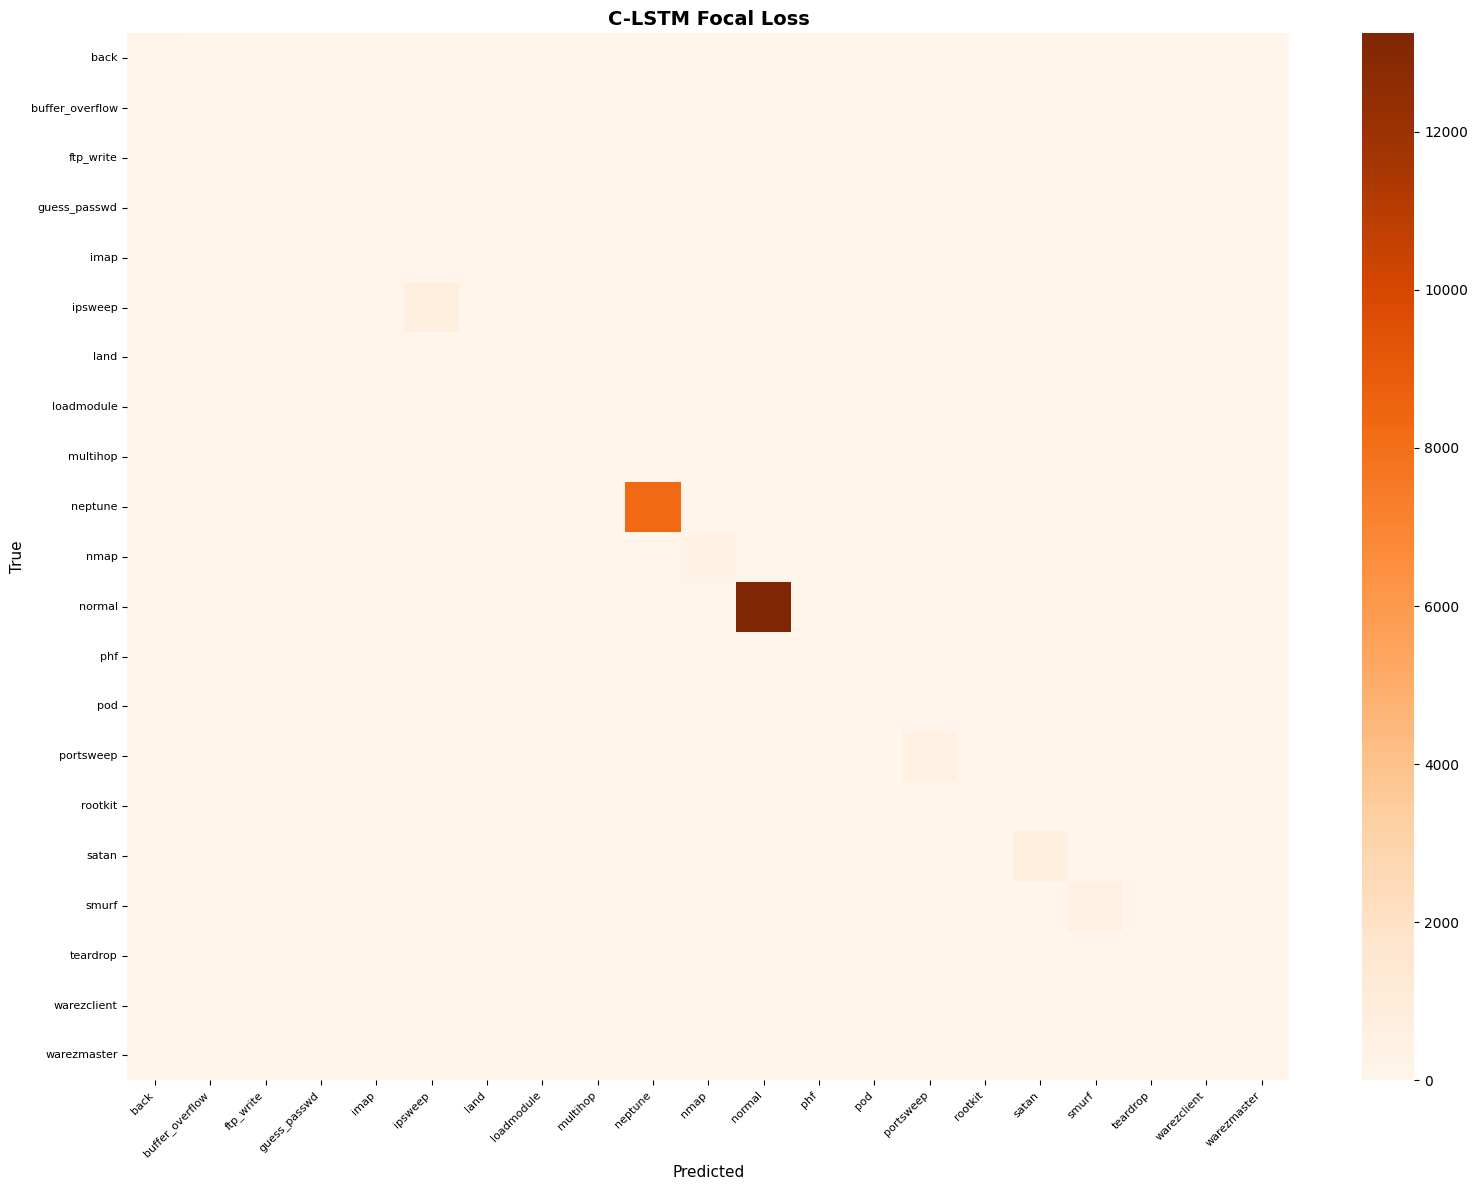

In [ ]:
class FocalLoss(nn.Module):
    """
    Focal Loss — Lin et al. (2017).
    FL(p_t) = -(1 - p_t)^gamma * log(p_t)
    gamma=0 recovers standard CrossEntropyLoss.
    gamma=2 is the standard recommendation for imbalanced problems.
    No additional class weights — Focal Loss already handles hard/easy imbalance.
    """
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, targets):
        ce   = F.cross_entropy(logits, targets, reduction='none')
        pt   = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()

focal_model     = CLSTM(input_dim, num_classes).to(device)
focal_criterion = FocalLoss(gamma=2.0)

focal_model, tl_focal, vl_focal = train_model(
    focal_model, loader, X_va_t, y_va_t,
    epochs=20, criterion=focal_criterion)
plot_losses(tl_focal, vl_focal, 'C-LSTM Focal Loss')
preds_focal, macro_focal, wtd_focal = evaluate(
    focal_model, X_te_t, y_test_full, "C-LSTM+FocalLoss")
plot_cm(y_test_full, preds_focal, 'C-LSTM Focal Loss', cmap='Oranges')
torch.save(focal_model.state_dict(), 'clstm_focal.pt')

---
## 7 · CNN-Transformer
*Replaces the LSTM with a multi-head Transformer Encoder. Attends to all positions simultaneously — captures longer-range feature interactions than the sequential LSTM.*  
> **Runtime: ~7 min on T4 GPU**

In [ ]:
class CNNTransformer(nn.Module):
    """
    CNN → Transformer Encoder → Global Average Pooling → Classifier.

    Key difference vs C-LSTM:
      LSTM: processes sequence left-to-right (causal, O(seq) steps).
      Transformer: attends to all positions in parallel (non-causal, O(1) depth).
    """
    def __init__(self, input_size, num_classes,
                 cnn_filters=64, nhead=4, num_layers=2,
                 dim_ff=256, dropout=0.3):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, cnn_filters, kernel_size=3, padding=1),
            nn.BatchNorm1d(cnn_filters), nn.ReLU(), nn.MaxPool1d(2),
        )
        enc_layer = nn.TransformerEncoderLayer(
            d_model=cnn_filters, nhead=nhead,
            dim_feedforward=dim_ff, dropout=dropout,
            batch_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.classifier  = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(cnn_filters, 64), nn.ReLU(),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.cnn(x.unsqueeze(1)).permute(0, 2, 1)  # [B, seq, 64]
        x = self.transformer(x).mean(dim=1)             # global avg pool
        return self.classifier(x)

transformer = CNNTransformer(input_dim, num_classes).to(device)
print(f"CNN-Transformer parameters: {sum(p.numel() for p in transformer.parameters() if p.requires_grad):,}")

CNN-Transformer parameters: 106,007


  Ep  5/20 | Train 0.0932 | Val 0.0848 ← best
  Ep 10/20 | Train 0.0540 | Val 0.0841
  Ep 15/20 | Train 0.0430 | Val 0.0754
  Ep 20/20 | Train 0.0376 | Val 0.0698
  Best val loss: 0.0564 at epoch 16 | 3.3 min


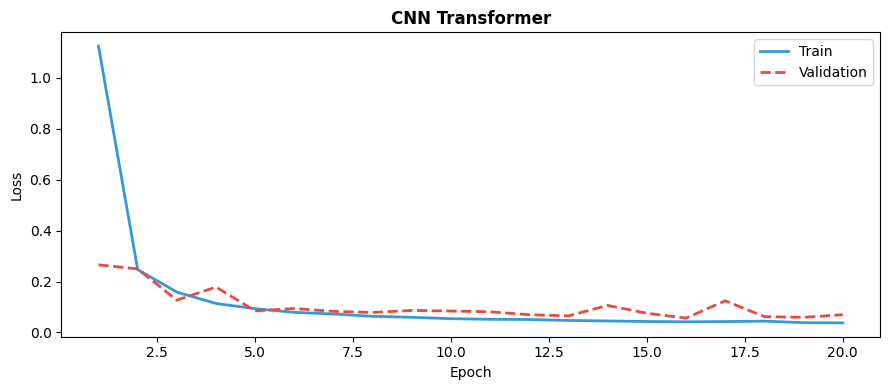


── CNN-Transformer ──
  Macro F1    : 0.6448
  Weighted F1 : 0.9893
                 precision    recall  f1-score   support

           back       0.90      0.98      0.94       191
buffer_overflow       0.08      0.83      0.15         6
      ftp_write       0.00      0.00      0.00         2
   guess_passwd       0.69      1.00      0.81        11
           imap       0.33      1.00      0.50         2
        ipsweep       0.96      0.98      0.97       720
           land       0.67      1.00      0.80         4
     loadmodule       0.11      0.50      0.18         2
       multihop       0.00      0.00      0.00         1
        neptune       1.00      1.00      1.00      8243
           nmap       0.93      0.97      0.95       299
         normal       1.00      0.98      0.99     13469
            phf       0.00      0.00      0.00         1
            pod       1.00      1.00      1.00        40
      portsweep       1.00      0.99      0.99       586
        rootkit   

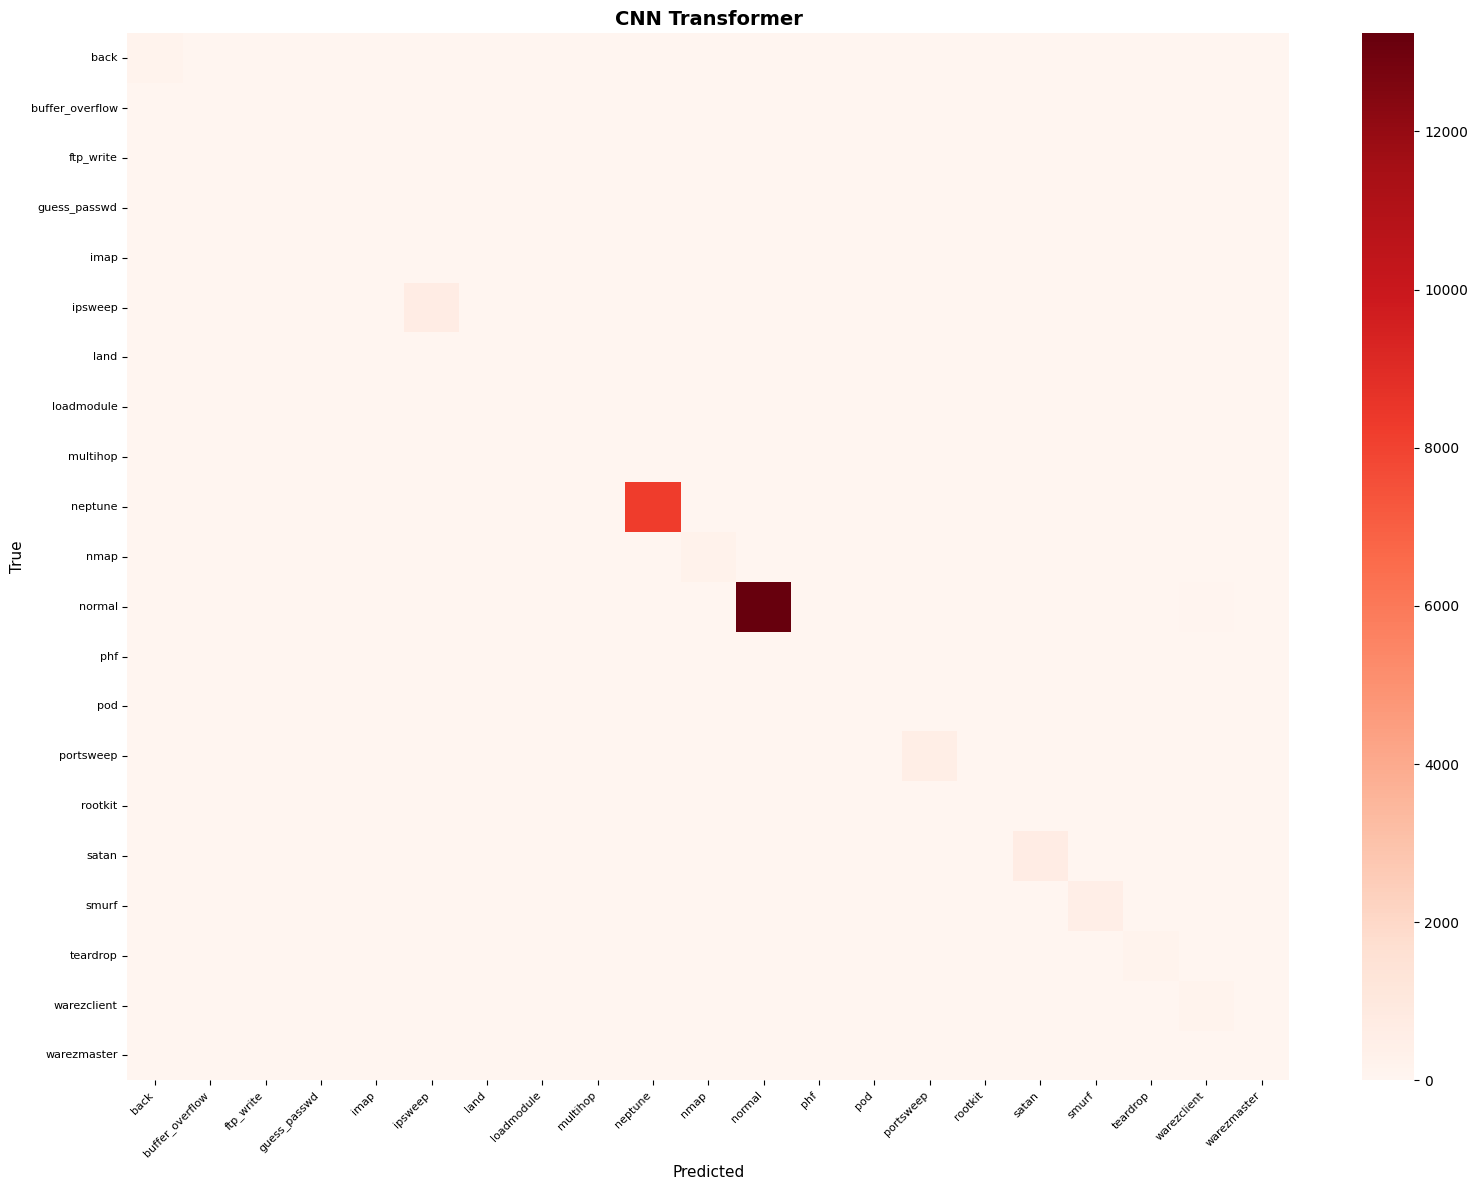

In [ ]:
transformer, tl_tf, vl_tf = train_model(
    transformer, loader, X_va_t, y_va_t, epochs=20)
plot_losses(tl_tf, vl_tf, 'CNN Transformer')
preds_tf, macro_tf, wtd_tf = evaluate(
    transformer, X_te_t, y_test_full, "CNN-Transformer")
plot_cm(y_test_full, preds_tf, 'CNN Transformer', cmap='Reds')
torch.save(transformer.state_dict(), 'cnn_transformer.pt')

---
## 8 · Architecture Comparison & Final Evaluation

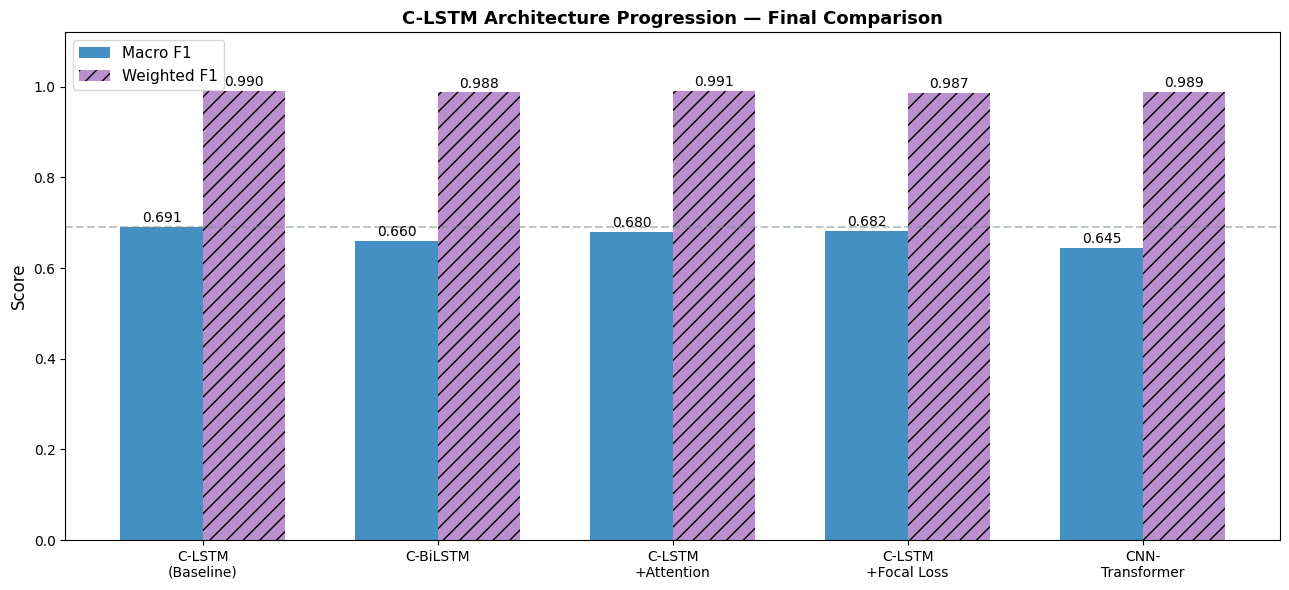

In [ ]:
results = {
    'C-LSTM\n(Baseline)':  {'macro': macro_base,  'weighted': wtd_base,  'tl': tl_base,  'vl': vl_base,  'preds': preds_base},
    'C-BiLSTM':             {'macro': macro_bi,    'weighted': wtd_bi,    'tl': tl_bi,    'vl': vl_bi,    'preds': preds_bi},
    'C-LSTM\n+Attention':  {'macro': macro_attn,  'weighted': wtd_attn,  'tl': tl_attn,  'vl': vl_attn,  'preds': preds_attn},
    'C-LSTM\n+Focal Loss': {'macro': macro_focal, 'weighted': wtd_focal, 'tl': tl_focal, 'vl': vl_focal, 'preds': preds_focal},
    'CNN-\nTransformer':   {'macro': macro_tf,    'weighted': wtd_tf,    'tl': tl_tf,    'vl': vl_tf,    'preds': preds_tf},
}

names     = list(results.keys())
macros    = [results[n]['macro']    for n in names]
weighteds = [results[n]['weighted'] for n in names]

x, w = np.arange(len(names)), 0.35
fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x - w/2, macros,    w, label='Macro F1',    color='#2980b9', alpha=0.87)
ax.bar(x + w/2, weighteds, w, label='Weighted F1', color='#8e44ad', alpha=0.60, hatch='//')
for i, (m, wt) in enumerate(zip(macros, weighteds)):
    ax.text(i-w/2, m+0.004,  f'{m:.3f}', ha='center', va='bottom', fontsize=10)
    ax.text(i+w/2, wt+0.004, f'{wt:.3f}', ha='center', va='bottom', fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=10)
ax.set_ylabel('Score', fontsize=12); ax.set_ylim(0, 1.12)
ax.set_title('C-LSTM Architecture Progression — Final Comparison',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(macro_base, linestyle='--', color='#7f8c8d',
           alpha=0.5, label=f'Baseline Macro ({macro_base:.3f})')
plt.tight_layout()
plt.savefig('architecture_comparison.png', dpi=150)
plt.show()

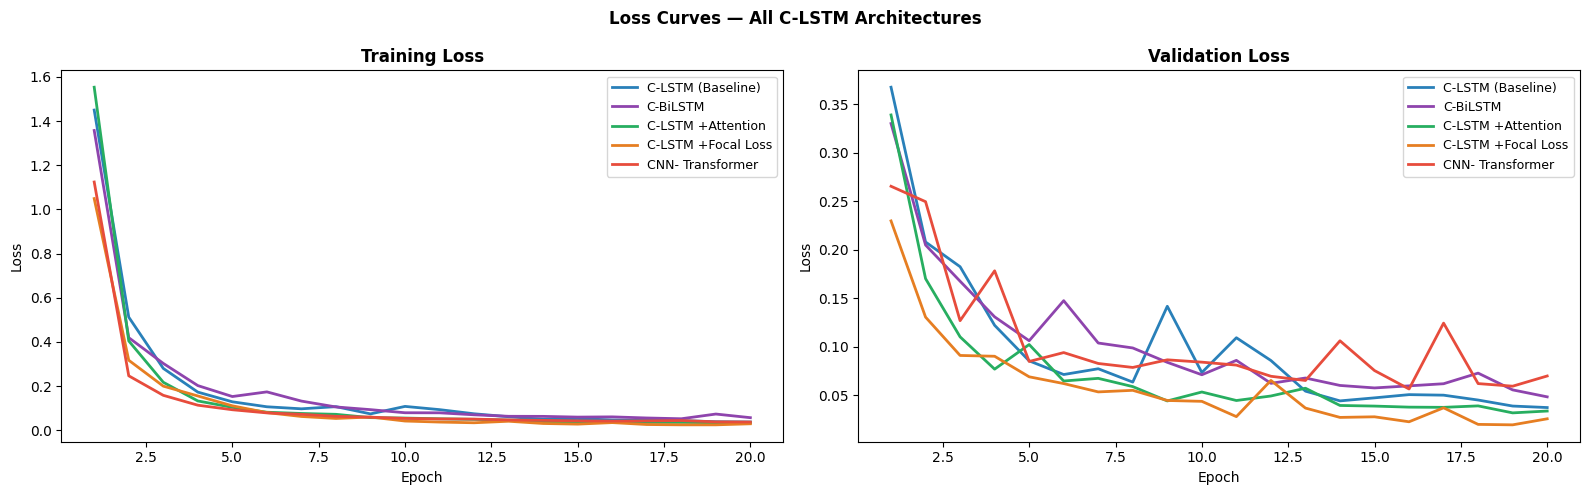

In [ ]:
# ── Loss curves overlay ──
colors = ['#2980b9', '#8e44ad', '#27ae60', '#e67e22', '#e74c3c']
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for (name, res), color in zip(results.items(), colors):
    clean = name.replace('\n', ' ')
    axes[0].plot(range(1, len(res['tl'])+1), res['tl'], label=clean, color=color, lw=2)
    axes[1].plot(range(1, len(res['vl'])+1), res['vl'], label=clean, color=color, lw=2)
for ax, title in zip(axes, ['Training Loss', 'Validation Loss']):
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(fontsize=9)
plt.suptitle('Loss Curves — All C-LSTM Architectures', fontweight='bold')
plt.tight_layout()
plt.savefig('all_loss_curves.png', dpi=150)
plt.show()

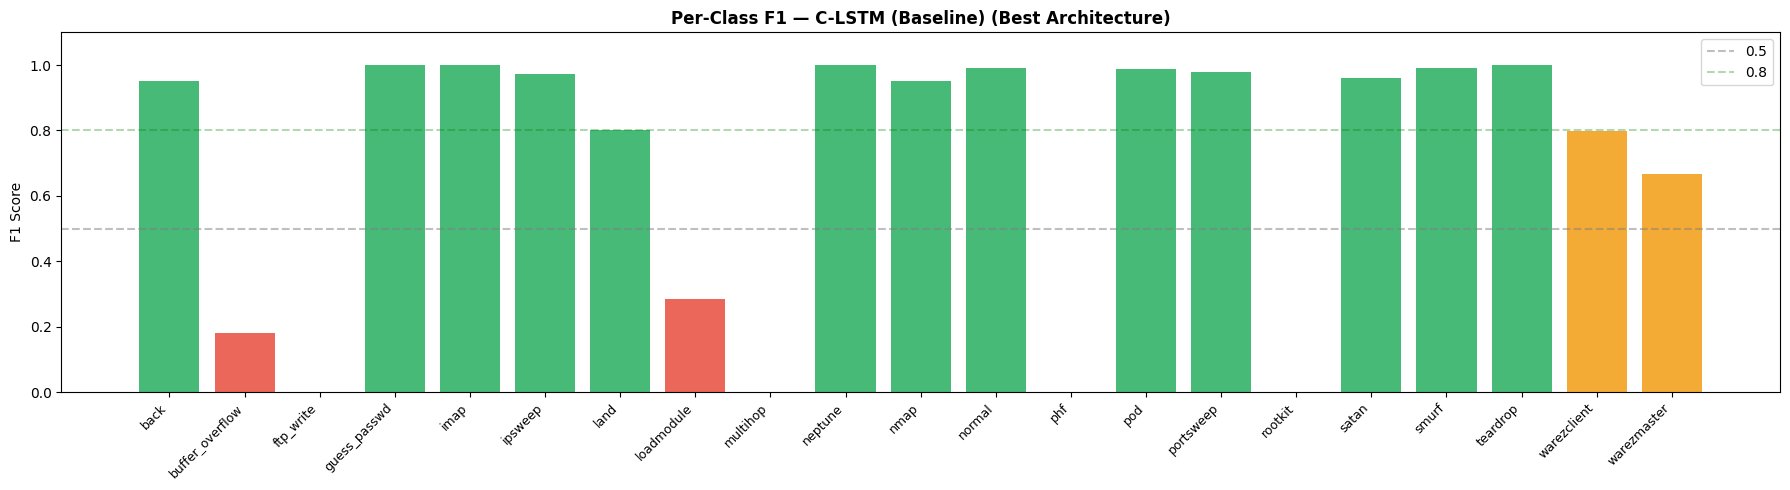

In [ ]:
# ── Per-class F1 for best architecture ──
best_idx   = int(np.argmax(macros))
best_name  = names[best_idx].replace('\n', ' ')
best_preds = results[names[best_idx]]['preds']

present = sorted(np.unique(np.concatenate([y_test_full, best_preds])))
pnames  = [target_names[i] for i in present]
report  = classification_report(y_test_full, best_preds, labels=present,
                                target_names=pnames, output_dict=True, zero_division=0)
f1s     = [report[n]['f1-score'] for n in pnames]
bar_colors = ['#e74c3c' if f < 0.5 else '#27ae60' if f >= 0.8 else '#f39c12' for f in f1s]

fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(pnames, f1s, color=bar_colors, alpha=0.85)
ax.set_xticks(range(len(pnames)))
ax.set_xticklabels(pnames, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('F1 Score'); ax.set_ylim(0, 1.1)
ax.axhline(0.5, linestyle='--', color='gray', alpha=0.5, label='0.5')
ax.axhline(0.8, linestyle='--', color='green', alpha=0.3, label='0.8')
ax.set_title(f'Per-Class F1 — {best_name} (Best Architecture)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('per_class_f1_best.png', dpi=150)
plt.show()

In [ ]:
# ── Summary table ──
print("=" * 60)
print("  FINAL C-LSTM ARCHITECTURE COMPARISON")
print("=" * 60)
print(f"{'Architecture':<28} {'Macro F1':>10} {'Weighted F1':>12}")
print("─" * 55)
for name, res in results.items():
    clean  = name.replace('\n', ' ')
    marker = '  ← best' if res['macro'] == max(macros) else ''
    print(f"{clean:<28} {res['macro']:>10.4f} {res['weighted']:>12.4f}{marker}")
print("=" * 60)

  FINAL C-LSTM ARCHITECTURE COMPARISON
Architecture                   Macro F1  Weighted F1
───────────────────────────────────────────────────────
C-LSTM (Baseline)                0.6910       0.9900  ← best
C-BiLSTM                         0.6597       0.9876
C-LSTM +Attention                0.6799       0.9914
C-LSTM +Focal Loss               0.6816       0.9867
CNN- Transformer                 0.6448       0.9893
